# Reto TC3302b - modelo inicial

María José Gaytán Gil A01706616

Maxime Vilcocq Parra A01710550

Salvador Rodríguez Paredes A01704562

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [22]:
df = pd.read_csv("fixed_dataset.csv")
df.head()

,File_1,File_2,seq_similarity,length_ratio,cosine_similarity,jaccard_similarity,depth_difference,Label
0,submission1.py,submission2.py,1.000000,1.000000,1.000000,1.000000,0,1
1,submission1.py,submission3.py,0.978261,1.000000,0.653022,0.750000,0,0
2,submission1.py,submission4.py,0.786787,0.707692,0.436094,0.777778,0,1
3,submission1.py,submission5.py,0.974729,0.992806,0.632365,0.750000,0,0
4,submission2.py,submission3.py,0.978261,1.000000,0.653022,0.750000,0,0


In [23]:
print("Dimensiones del dataset:", df.shape)
df.info()
df["Label"].value_counts()

Dimensiones del dataset: (293, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   File_1              293 non-null    object 
 1   File_2              293 non-null    object 
 2   seq_similarity      293 non-null    float64
 3   length_ratio        293 non-null    float64
 4   cosine_similarity   293 non-null    float64
 5   jaccard_similarity  293 non-null    float64
 6   depth_difference    293 non-null    int64  
 7   Label               293 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 18.4+ KB


,count
Label,
0,193
1,100


In [24]:
# Separar variables
X = df[
    [
        "length_ratio",
        "seq_similarity",
        "cosine_similarity",
        "jaccard_similarity",
        "depth_difference"
    ]
]

y = df["Label"]

In [25]:
# Dividir Dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (175, 5)
Validation: (59, 5)
Test: (59, 5)


In [26]:
# Escalar Datos
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [27]:
# Hiperparámetros
eta = 0.001
batch_size = 16
epochs = 300

optimizer = tf.keras.optimizers.Adam(learning_rate=eta)

In [28]:
# Modelo inicial
model = Sequential()

model.add(Dense(
    32,
    activation="relu",
    input_shape=(X_train.shape[1],)
))

model.add(Dropout(0.20))

model.add(Dense(
    16,
    activation="relu"
))

model.add(Dropout(0.20))

model.add(Dense(
    1,
    activation="sigmoid"
))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [30]:
# Callback
class MetricsCallback(Callback):

    def __init__(self, X_train, y_train, X_val, y_val):
        super().__init__()

        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val

        self.train_accuracy = []
        self.train_precision = []
        self.train_recall = []
        self.train_f1 = []

        self.val_accuracy = []
        self.val_precision = []
        self.val_recall = []
        self.val_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_pred_prob = self.model.predict(self.X_train, verbose=0)
        train_pred = (train_pred_prob > 0.5).astype(int).ravel()

        val_pred_prob = self.model.predict(self.X_val, verbose=0)
        val_pred = (val_pred_prob > 0.5).astype(int).ravel()

        train_acc = accuracy_score(self.y_train, train_pred)
        train_pre = precision_score(self.y_train, train_pred, zero_division=0)
        train_rec = recall_score(self.y_train, train_pred, zero_division=0)
        train_f1 = f1_score(self.y_train, train_pred, zero_division=0)

        val_acc = accuracy_score(self.y_val, val_pred)
        val_pre = precision_score(self.y_val, val_pred, zero_division=0)
        val_rec = recall_score(self.y_val, val_pred, zero_division=0)
        val_f1 = f1_score(self.y_val, val_pred, zero_division=0)

        self.train_accuracy.append(train_acc)
        self.train_precision.append(train_pre)
        self.train_recall.append(train_rec)
        self.train_f1.append(train_f1)

        self.val_accuracy.append(val_acc)
        self.val_precision.append(val_pre)
        self.val_recall.append(val_rec)
        self.val_f1.append(val_f1)

        logs["val_f1"] = val_f1

In [31]:
metrics_callback = MetricsCallback(
    X_train,
    y_train,
    X_val,
    y_val
)

early_stopping = EarlyStopping(
    monitor="val_f1",
    mode="max",
    patience=30,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="modeloInicialPlagio.keras",
    monitor="val_f1",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [32]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[
        metrics_callback,
        early_stopping,
        checkpoint
    ],
    verbose=1
)

Epoch 1/300
 1/11 ━━━━━━━━━━━━━━━━━━━━ 52s 5s/step - accuracy: 0.3750 - loss: 1.0216 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 1: val_f1 improved from None to 0.29412, saving model to modeloInicialPlagio.keras

Epoch 1: finished saving model to modeloInicialPlagio.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.4400 - loss: 0.7543 - precision: 0.2361 - recall: 0.2833 - val_accuracy: 0.5932 - val_loss: 0.6809 - val_precision: 0.3571 - val_recall: 0.2500 - val_f1: 0.2941
Epoch 2/300
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6250 - loss: 0.6712 - precision: 0.3333 - recall: 0.5000
Epoch 2: val_f1 improved from 0.29412 to 0.41176, saving model to modeloInicialPlagio.keras

Epoch 2: finished saving model to modeloInicialPlagio.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.6057 - loss: 0.6841 - precision: 0.4151 - recall: 0.3667 - val_accuracy: 0.6610 - val_loss: 0.6231 - val_precision: 0.5000 - val_recall: 0.3500 - val_f1: 0.4118
Epoch 3/300
 

In [40]:
best_model = tf.keras.models.load_model("modeloInicialPlagio.keras")

In [41]:
# Predicciones
train_pred_prob = best_model.predict(X_train)
train_pred = (train_pred_prob > 0.5).astype(int).ravel()

val_pred_prob = best_model.predict(X_val)
val_pred = (val_pred_prob > 0.5).astype(int).ravel()

test_pred_prob = best_model.predict(X_test)
test_pred = (test_pred_prob > 0.5).astype(int).ravel()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [42]:
# métricas
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

In [43]:
# Comparación
train_metrics = get_metrics(y_train, train_pred)
validation_metrics = get_metrics(y_val, val_pred)
test_metrics = get_metrics(y_test, test_pred)

comparison_df = pd.DataFrame({
    "Train": train_metrics,
    "Validation": validation_metrics,
    "Test": test_metrics
})

comparison_df

,Train,Validation,Test
Accuracy,0.834286,0.864407,0.830508
Precision,0.746032,0.800000,0.857143
Recall,0.783333,0.800000,0.600000
F1-score,0.764228,0.800000,0.705882


REPORTE POR CLASE - VALIDATION

               precision    recall  f1-score   support

No Plagiarism       0.90      0.90      0.90        39
   Plagiarism       0.80      0.80      0.80        20

     accuracy                           0.86        59
    macro avg       0.85      0.85      0.85        59
 weighted avg       0.86      0.86      0.86        59



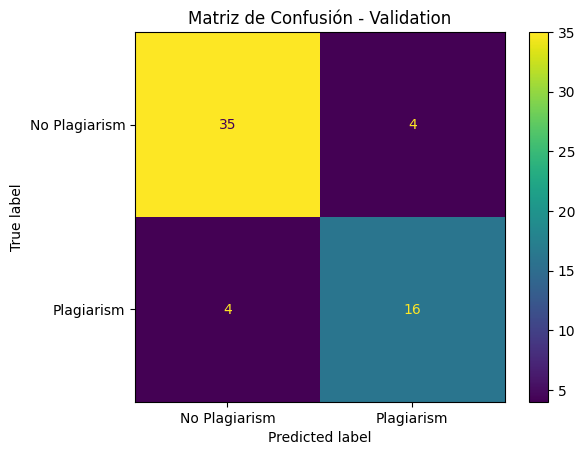

In [44]:
# Reporte de Validation
print("REPORTE POR CLASE - VALIDATION\n")

print(
    classification_report(
        y_val,
        val_pred,
        target_names=["No Plagiarism", "Plagiarism"],
        zero_division=0
    )
)

cm_val = confusion_matrix(y_val, val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["No Plagiarism", "Plagiarism"]
)

disp.plot()
plt.title("Matriz de Confusión - Validation")
plt.show()

REPORTE POR CLASE - TEST

               precision    recall  f1-score   support

No Plagiarism       0.82      0.95      0.88        39
   Plagiarism       0.86      0.60      0.71        20

     accuracy                           0.83        59
    macro avg       0.84      0.77      0.79        59
 weighted avg       0.83      0.83      0.82        59



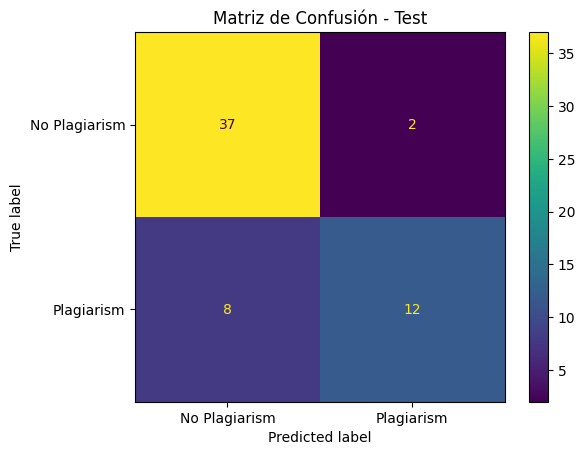

In [45]:
# Reporte de Test
print("REPORTE POR CLASE - TEST\n")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=["No Plagiarism", "Plagiarism"],
        zero_division=0
    )
)

cm_test = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["No Plagiarism", "Plagiarism"]
)

disp.plot()
plt.title("Matriz de Confusión - Test")
plt.show()

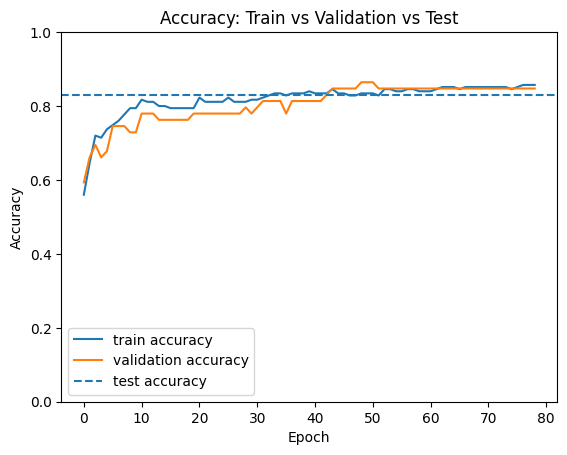

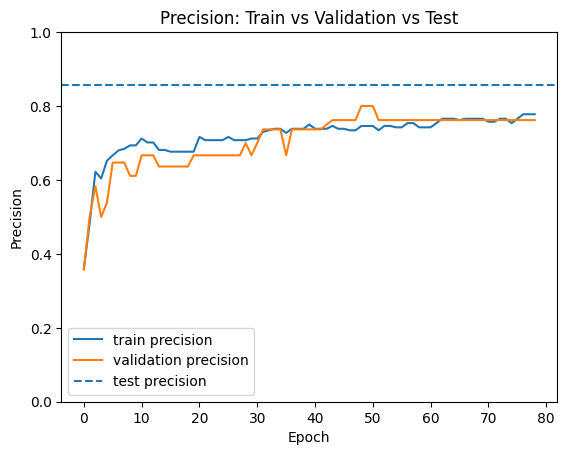

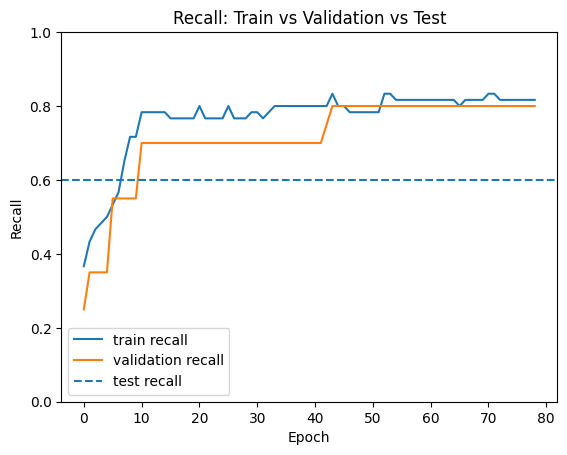

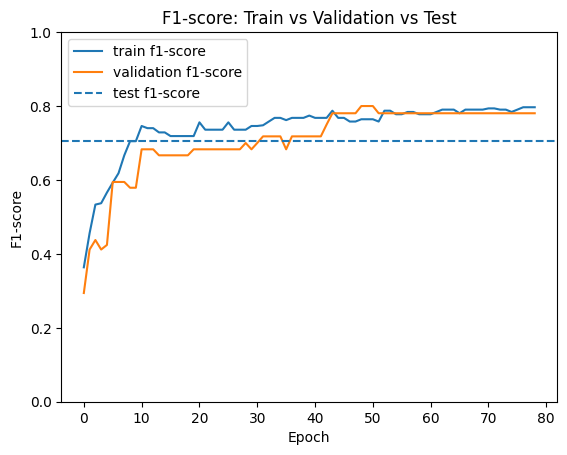

In [46]:
# Gráficas
plt.plot(metrics_callback.train_accuracy, label="train accuracy")
plt.plot(metrics_callback.val_accuracy, label="validation accuracy")
plt.axhline(y=test_metrics["Accuracy"], linestyle="--", label="test accuracy")
plt.ylim(0, 1)
plt.title("Accuracy: Train vs Validation vs Test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(metrics_callback.train_precision, label="train precision")
plt.plot(metrics_callback.val_precision, label="validation precision")
plt.axhline(y=test_metrics["Precision"], linestyle="--", label="test precision")
plt.ylim(0, 1)
plt.title("Precision: Train vs Validation vs Test")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.legend()
plt.show()


plt.plot(metrics_callback.train_recall, label="train recall")
plt.plot(metrics_callback.val_recall, label="validation recall")
plt.axhline(y=test_metrics["Recall"], linestyle="--", label="test recall")
plt.ylim(0, 1)
plt.title("Recall: Train vs Validation vs Test")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()
plt.show()

plt.plot(metrics_callback.train_f1, label="train f1-score")
plt.plot(metrics_callback.val_f1, label="validation f1-score")
plt.axhline(y=test_metrics["F1-score"], linestyle="--", label="test f1-score")
plt.ylim(0, 1)
plt.title("F1-score: Train vs Validation vs Test")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.show()